# Homework 4.2 — Regression discontinuity at score 80

## tl;dr

| Quiz question | Answer | Evidence |
|---|---|---|
| Q3: Dataset with a clear nonzero linear score trend | **A — Dataset b (X2, Y2)** | Before-cutoff probability slope = **0.010217** per score point |
| Q4: Direction before the cutoff in that dataset | **B — Increasing** | The before-cutoff slope is positive |
| Q5: Slope after versus before the cutoff | **A — Lower** | Probability slope falls from **0.010217** to **0.005009** |

These answers use the slope of expected **Y (admission probability)**.
Dataset b rises by about **1.02 percentage points per score point before 80**,
and **0.50 percentage points afterward**. Both datasets have an upward jump
at 80. Questions 1–2 are in `homework_4.1_instrumental_variables.ipynb`.

## Context & Methods

Sources: `homework_4.2.a.csv` (X, Y) and `homework_4.2.b.csv` (X2, Y2)
in the project folder. Each file contains 100,000 students and a binary
college-admission outcome. Rename the columns to score and admitted within
the analysis, preserving the source files.

Let $x=X-80$ and $D=1[X\geq80]$. To answer the questions about a **linear
relationship of Y to X**, fit the segmented linear probability model:

$$E[Y\mid X]=\alpha+\beta x+\delta D+\gamma xD.$$

The before slope is $\beta$, the after slope is $\beta+\gamma$, the slope
change is $\gamma$, and the cutoff jump is $\delta$. Use all supplied
observations and heteroskedasticity-robust HC1 standard errors because Y is binary.
Report normal-approximation tests and 95% confidence intervals.

Also fit a segmented **logistic regression locally within scores 70–90**,
and plot its predicted probability against admission rates in one-point score
bins. This avoids an unreadable scatter of individual zero/one outcomes.
Repeat the local fit within 75–85 as a bandwidth check.

### Key Assumptions

- Students just above and below 80 must be comparable, untreated admission
  probabilities must be continuous, and no other policy can change at 80 for
  the cutoff jump to have a causal interpretation.
- The files contain no course-attendance indicator. An upward jump supports
  a beneficial course effect **if course eligibility starts at or above 80**
  and the regression-discontinuity assumptions hold. The files alone do not
  establish the treatment assignment rule or compliance.
- Probability slopes and log-odds coefficients use different scales. For a
  logistic fit, the probability slope is $p(1-p)$ times the log-odds slope.
  The additional scale check below explains why this distinction matters for Q5.
- Repeated rows are retained. All duplicate score/outcome combinations occur
  at the capped score of 100; two students can have the same score and outcome.

Setup if needed: `%pip install numpy pandas scipy matplotlib scikit-learn`.
Keep both CSVs in the project folder above `Homework Code`.

## Data

### 1. Set up the analysis

In [1]:
from pathlib import Path
import hashlib
import importlib.metadata
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display, Markdown

pd.set_option('display.precision', 6)
plt.rcParams.update({
    'figure.figsize': (9, 4.8), 'figure.dpi': 110, 'font.size': 11,
    'axes.titlesize': 13, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#E5E7EB', 'axes.axisbelow': True,
    'text.color': '#1F2937', 'axes.labelcolor': '#1F2937',
})
BLUE, GOLD, DARK = '#2563EB', '#B7791F', '#374151'

def locate_csv(filename):
    # Works from the project folder, Homework Code, or HW4.
    for folder in (Path.cwd(), *Path.cwd().parents):
        path = folder / filename
        if path.is_file():
            return path.resolve()
    raise FileNotFoundError(f'Cannot find {filename} above the working directory.')

def show_table(frame, formats=None):
    display(frame.style.hide(axis='index').format(formats or {}, na_rep='—'))

def validate_numeric(frame):
    if not all(pd.api.types.is_numeric_dtype(frame[c]) for c in frame):
        raise TypeError('All analysis columns must be numeric.')
    if not np.isfinite(frame.to_numpy()).all():
        raise ValueError('Missing or infinite analysis values.')

### 2. Load and check the datasets

In [2]:
CUTOFF = 80
datasets = {}
audit = []
for label, filename, names in [
    ('Dataset a', 'homework_4.2.a.csv', ['X', 'Y']),
    ('Dataset b', 'homework_4.2.b.csv', ['X2', 'Y2']),
]:
    path = locate_csv(filename)
    source = pd.read_csv(path)
    if not set(names).issubset(source.columns):
        raise ValueError(f'{filename}: expected {names}')
    frame = source[names].copy()
    frame.columns = ['score', 'admitted']
    validate_numeric(frame)
    assert set(frame['admitted'].unique()) == {0, 1}
    assert frame.loc[frame.duplicated(), 'score'].eq(100).all()
    datasets[label] = frame
    audit.append({'Dataset': label, 'Rows': len(frame),
                  'Before 80': int((frame['score'] < CUTOFF).sum()),
                  'At/above 80': int((frame['score'] >= CUTOFF).sum()),
                  'Duplicate rows retained': int(frame.duplicated().sum()),
                  'Rows at score 100': int(frame['score'].eq(100).sum())})
    print(f'{filename} SHA-256: {hashlib.sha256(path.read_bytes()).hexdigest()}')
show_table(pd.DataFrame(audit))

homework_4.2.a.csv SHA-256: b9f5670015bde68e1ad2628e00a13353abc57bf15694279a2b5685e9b10acbb5
homework_4.2.b.csv SHA-256: 3707084a9c950df1d5ed1d6a89b83bffea2c9dd92a231d55f2cb3619f186edc7


Dataset,Rows,Before 80,At/above 80,Duplicate rows retained,Rows at score 100
Dataset a,100000,49926,50074,2296,2298
Dataset b,100000,50068,49932,2255,2256


## Results

### 3. Fit separate probability slopes around the cutoff

In [3]:
TERMS = ['Intercept at 80 (before)', 'Slope before', 'Jump at 80', 'Slope change']

def make_design(score):
    centered = np.asarray(score) - CUTOFF
    after = (centered >= 0).astype(float)
    return np.column_stack([np.ones(len(centered)), centered, after, centered * after])

def linear_probability_fit(frame):
    X = make_design(frame['score'])
    y = frame['admitted'].to_numpy()
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    residual = y - X @ beta
    n, k = X.shape
    bread = np.linalg.inv(X.T @ X)
    # HC1 sandwich covariance handles the binary outcome's nonconstant variance.
    meat = X.T @ ((residual ** 2)[:, None] * X)
    covariance = (n / (n - k)) * bread @ meat @ bread
    se = np.sqrt(np.diag(covariance))
    z = beta / se
    coefficients = pd.DataFrame({
        'Term': TERMS, 'Estimate': beta, 'Robust SE': se, 'z': z,
        'p-value': 2 * stats.norm.sf(np.abs(z)),
        '95% CI lower': beta - stats.norm.ppf(.975) * se,
        '95% CI upper': beta + stats.norm.ppf(.975) * se,
    })
    return {'beta': beta, 'covariance': covariance, 'coefficients': coefficients}

linear_models = {label: linear_probability_fit(frame) for label, frame in datasets.items()}
coefficient_table = pd.concat([
    model['coefficients'].assign(Dataset=label)
    for label, model in linear_models.items()
], ignore_index=True)
coefficient_table = coefficient_table[['Dataset', 'Term', 'Estimate', 'Robust SE',
                                      'z', 'p-value', '95% CI lower', '95% CI upper']]
formats = {column: '{:.6f}' for column in ['Estimate', 'Robust SE', 'z',
                                          '95% CI lower', '95% CI upper']}
formats['p-value'] = lambda value: '<1e-300' if value < 1e-300 else f'{value:.3e}'
show_table(coefficient_table, formats)

Dataset,Term,Estimate,Robust SE,z,p-value,95% CI lower,95% CI upper
Dataset a,Intercept at 80 (before),0.304997,0.003415,89.309748,<1e-300,0.298303,0.311690
Dataset a,Slope before,0.000224,0.000341,0.657094,5.111e-01,-0.000444,0.000891
Dataset a,Jump at 80,0.295757,0.005081,58.204655,<1e-300,0.285798,0.305716
Dataset a,Slope change,-0.000063,0.000520,-0.120712,9.039e-01,-0.001081,0.000956
Dataset b,Intercept at 80 (before),0.702345,0.003503,200.484559,<1e-300,0.695479,0.709211
Dataset b,Slope before,0.010217,0.000359,28.427917,9.139e-178,0.009512,0.010921
Dataset b,Jump at 80,0.197112,0.004046,48.712916,<1e-300,0.189181,0.205043
Dataset b,Slope change,-0.005208,0.000393,-13.242945,4.957e-40,-0.005979,-0.004437


### 4. Q3–Q5 — Compare the linear trends

In [4]:
trend_rows = []
for label, model in linear_models.items():
    beta = model['beta']
    trend_rows.append({'Dataset': label, 'Slope before': beta[1],
                      'Slope after': beta[1] + beta[3], 'Slope change': beta[3],
                      'Cutoff jump': beta[2]})
trend_table = pd.DataFrame(trend_rows)
show_table(trend_table, {c: '{:.6f}' for c in trend_table.columns if c != 'Dataset'})

b = linear_models['Dataset b']['beta']
display(Markdown(
    f'**Q3: A — Dataset b. Q4: B — Increasing. Q5: A — Lower.** '
    f'Its before slope is {b[1]:.6f} and its after slope is {b[1] + b[3]:.6f}, '
    f'a change of {b[3]:.6f} per score point.'
))

Dataset,Slope before,Slope after,Slope change,Cutoff jump
Dataset a,0.000224,0.000161,-0.000063,0.295757
Dataset b,0.010217,0.005009,-0.005208,0.197112


**Q3: A — Dataset b. Q4: B — Increasing. Q5: A — Lower.** Its before slope is 0.010217 and its after slope is 0.005009, a change of -0.005208 per score point.

Dataset a has no convincing linear score trend (before-slope p ≈ 0.511; slope-change p ≈ 0.904). Dataset b has a positive before slope and a negative slope change (p ≈ 4.96 × 10⁻⁴⁰). Its expected admission probability still increases after 80, but more slowly.

### 5. Plot admission rates and the linear probability fits

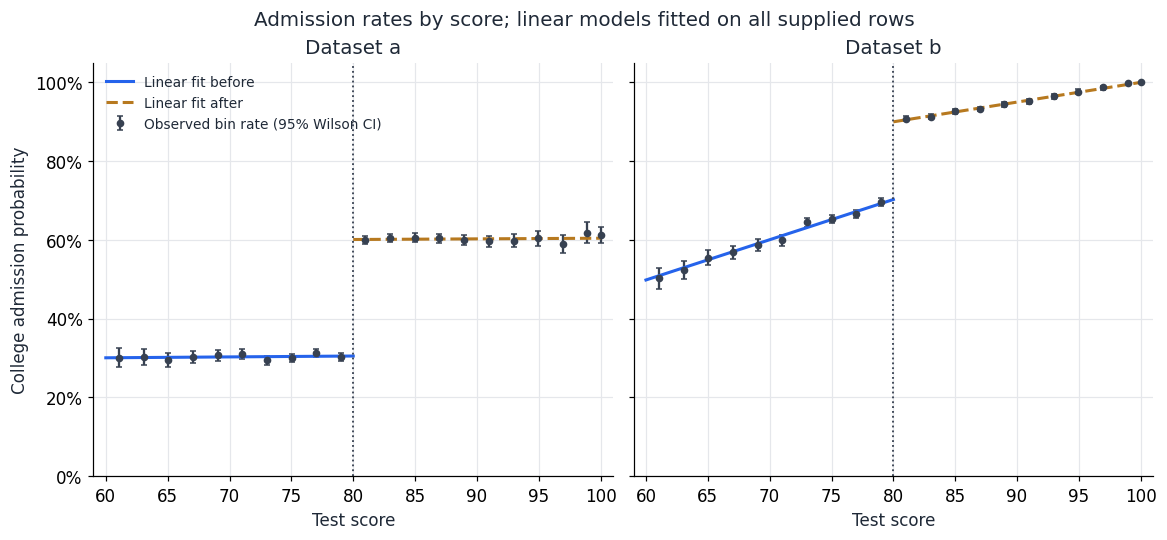

In [5]:
from matplotlib.ticker import PercentFormatter

def binned_rates(frame, edges):
    working = frame.assign(score_bin=pd.cut(frame['score'], edges, right=False))
    rates = working.groupby('score_bin', observed=True).agg(
        score=('score', 'mean'), rate=('admitted', 'mean'), n=('admitted', 'size')
    ).reset_index(drop=True)
    # Wilson 95% intervals for each observed binomial admission rate.
    z = stats.norm.ppf(.975)
    denominator = 1 + z ** 2 / rates['n']
    center = (rates['rate'] + z ** 2 / (2 * rates['n'])) / denominator
    half = z * np.sqrt(rates['rate'] * (1 - rates['rate']) / rates['n']
                        + z ** 2 / (4 * rates['n'] ** 2)) / denominator
    rates['lower'] = center - half
    rates['upper'] = center + half
    return rates

def plot_observed_rates(ax, rates):
    errors = np.vstack([rates['rate'] - rates['lower'], rates['upper'] - rates['rate']])
    # At a rate of 100%, roundoff can make the zero-length upper error slightly negative.
    assert errors.min() > -1e-12
    ax.errorbar(rates['score'], rates['rate'],
                yerr=np.maximum(errors, 0),
                fmt='o', color=DARK, markersize=4, capsize=2,
                label='Observed bin rate (95% Wilson CI)')

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.8), sharey=True, constrained_layout=True)
for ax, (label, frame) in zip(axes, datasets.items()):
    rates = binned_rates(frame, np.arange(60, 103, 2))
    plot_observed_rates(ax, rates)
    beta = linear_models[label]['beta']
    for low, high, color, linestyle, line_label in [
        (60, 80 - 1e-6, BLUE, '-', 'Linear fit before'),
        (80, 100, GOLD, '--', 'Linear fit after'),
    ]:
        scores = np.linspace(low, high, 200)
        ax.plot(scores, make_design(scores) @ beta, color=color, linestyle=linestyle,
                linewidth=2, label=line_label)
    ax.axvline(CUTOFF, color=DARK, linestyle=':', linewidth=1.2)
    ax.set_title(label)
    ax.set_xlabel('Test score')
    ax.set_xlim(59, 101)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
axes[0].set_ylabel('College admission probability')
axes[0].legend(frameon=False, fontsize=9, loc='upper left')
fig.suptitle('Admission rates by score; linear models fitted on all supplied rows', fontsize=13)
plt.show()

The plot displays scores 60–100 in two-point bins, with score 100 in its own final bin. Dataset a is approximately flat on each side of the cutoff. Dataset b increases on both sides, with a flatter post-cutoff trend. The estimated upward jumps are 29.58 percentage points in a and 19.71 percentage points in b.

### 6. Fit logistic regression locally around 80

In [6]:
from scipy.optimize import minimize
from scipy.special import expit

def logistic_fit(frame, bandwidth=None):
    local = frame if bandwidth is None else frame.loc[(frame['score'] - CUTOFF).abs() <= bandwidth]
    X = make_design(local['score'])
    y = local['admitted'].to_numpy()

    def objective(beta):
        eta = X @ beta
        return np.sum(np.logaddexp(0, eta) - y * eta)

    def gradient(beta):
        return X.T @ (expit(X @ beta) - y)

    def hessian(beta):
        probability = expit(X @ beta)
        return X.T @ ((probability * (1 - probability))[:, None] * X)

    result = minimize(objective, np.zeros(4), jac=gradient, hess=hessian,
                      method='Newton-CG', options={'xtol': 1e-10, 'maxiter': 100})
    if not result.success:
        raise RuntimeError(result.message)
    if np.max(np.abs(gradient(result.x))) / len(local) > 1e-7:
        raise RuntimeError('Logistic score equations did not converge sufficiently.')
    return {'beta': result.x, 'n': len(local), 'bandwidth': bandwidth}

def probability_at_cutoff(model):
    beta = model['beta']
    p_before = expit(beta[0])
    p_after = expit(beta[0] + beta[2])
    return {'Probability before': p_before, 'Probability after': p_after,
            'Probability jump': p_after - p_before,
            'Probability slope before': p_before * (1 - p_before) * beta[1],
            'Probability slope after': p_after * (1 - p_after) * (beta[1] + beta[3])}

BANDWIDTH = 10
local_models = {label: logistic_fit(frame, BANDWIDTH) for label, frame in datasets.items()}
local_table = pd.DataFrame([
    {'Dataset': label, 'Rows': model['n'], **probability_at_cutoff(model)}
    for label, model in local_models.items()
])
show_table(local_table, {c: '{:.6f}' for c in local_table.columns if c not in ['Dataset', 'Rows']})

Dataset,Rows,Probability before,Probability after,Probability jump,Probability slope before,Probability slope after
Dataset a,68233,0.305246,0.600404,0.295158,0.000367,0.000466
Dataset b,68139,0.701400,0.898843,0.197443,0.009440,0.006068


These logistic results refer to the left and right limits at score 80. For dataset b within 70–90, the probability slope is about **0.00944 before** and **0.00607 after**, supporting the same directions as the linear probability model.

### 7. Compare observed rates with local logistic predictions

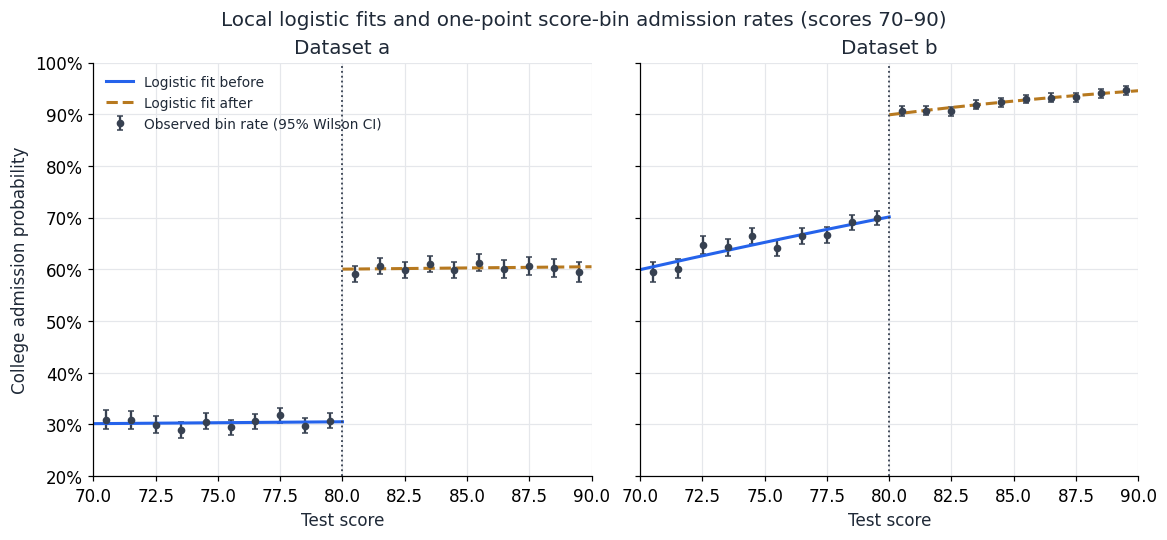

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.8), sharey=True, constrained_layout=True)
for ax, (label, frame) in zip(axes, datasets.items()):
    plot_observed_rates(ax, binned_rates(frame, np.arange(70, 91, 1)))
    beta = local_models[label]['beta']
    for low, high, color, linestyle, line_label in [
        (70, 80 - 1e-6, BLUE, '-', 'Logistic fit before'),
        (80, 90, GOLD, '--', 'Logistic fit after'),
    ]:
        scores = np.linspace(low, high, 200)
        ax.plot(scores, expit(make_design(scores) @ beta), color=color,
                linestyle=linestyle, linewidth=2, label=line_label)
    ax.axvline(CUTOFF, color=DARK, linestyle=':', linewidth=1.2)
    ax.set_title(label)
    ax.set_xlabel('Test score')
    ax.set_xlim(70, 90)
    ax.set_ylim(.2, 1)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
axes[0].set_ylabel('College admission probability')
axes[0].legend(frameon=False, fontsize=9, loc='upper left')
fig.suptitle('Local logistic fits and one-point score-bin admission rates (scores 70–90)', fontsize=13)
plt.show()

### 8. Check bandwidth and distinguish probability from log-odds slopes

In [8]:
sensitivity = []
for bandwidth in [5, 10]:
    model = logistic_fit(datasets['Dataset b'], bandwidth)
    quantities = probability_at_cutoff(model)
    sensitivity.append({'Score window': f'{CUTOFF-bandwidth}–{CUTOFF+bandwidth}',
        'Rows': model['n'], 'Probability jump': quantities['Probability jump'],
        'Slope before': quantities['Probability slope before'],
        'Slope after': quantities['Probability slope after']})
show_table(pd.DataFrame(sensitivity), {c: '{:.6f}' for c in
    ['Probability jump', 'Slope before', 'Slope after']})

global_logit = logistic_fit(datasets['Dataset b'])
beta_logit = global_logit['beta']
show_table(pd.DataFrame({
    'All-row logistic coefficient': ['Log-odds slope before', 'Log-odds slope after'],
    'Value': [beta_logit[1], beta_logit[1] + beta_logit[3]],
}), {'Value': '{:.6f}'})

Score window,Rows,Probability jump,Slope before,Slope after
75–85,38229,0.195810,0.012699,0.004582
70–90,68139,0.197443,0.009440,0.006068


All-row logistic coefficient,Value
Log-odds slope before,0.042977
Log-odds slope after,0.106181


**Q5 interpretation:** the outcome/probability slope is lower after the cutoff
in the segmented linear model and in both local logistic fits above. An
all-row logistic model instead has **log-odds** slopes of about 0.04298 before
and 0.10618 after. If the course uses “slope” specifically to mean those
full-sample logistic coefficients, it would imply **B — Higher** on that scale.
That is a different comparison from the slope of expected Y asked here.
The recommended answer **A — Lower** uses the linear probability relationship
and the local probability plots. The binary outcomes approach 100% at high
scores, so a global logistic model's shape and coefficient interpretation
need particular care.

### 9. Verify the linear slopes and local logistic calculations

In [9]:
from sklearn.linear_model import LinearRegression

for label, frame in datasets.items():
    X = make_design(frame['score'])
    model = linear_models[label]
    check = LinearRegression(fit_intercept=False).fit(X, frame['admitted'])
    np.testing.assert_allclose(check.coef_, model['beta'], atol=1e-12)
    before = frame.loc[frame['score'] < CUTOFF]
    after = frame.loc[frame['score'] >= CUTOFF]
    separate_before = stats.linregress(before['score'], before['admitted']).slope
    separate_after = stats.linregress(after['score'], after['admitted']).slope
    np.testing.assert_allclose(separate_before, model['beta'][1], atol=1e-12)
    np.testing.assert_allclose(separate_after, model['beta'][1] + model['beta'][3], atol=1e-12)

    # Numerically check the logistic probability derivatives at each cutoff limit.
    beta = local_models[label]['beta']
    quantities = probability_at_cutoff(local_models[label])
    step = 1e-5
    for side, offset, slope, target in [
        ('before', beta[0], beta[1], quantities['Probability slope before']),
        ('after', beta[0] + beta[2], beta[1] + beta[3], quantities['Probability slope after']),
    ]:
        numerical = (expit(offset + slope * step) - expit(offset - slope * step)) / (2 * step)
        np.testing.assert_allclose(numerical, target, atol=1e-10)

b = linear_models['Dataset b']['beta']
assert b[1] > 0 and 0 < b[1] + b[3] < b[1]
print('Checks passed: independent OLS coefficients, separate segment slopes, and logistic derivatives.')

Checks passed: independent OLS coefficients, separate segment slopes, and logistic derivatives.


## Takeaways

For the outcome/probability interpretation, select **Q3: A — Dataset b**, **Q4: B — Increasing**, and **Q5: A — Lower**. Dataset b has a positive trend on each side and a smaller slope after 80. Both datasets have positive cutoff jumps; linking those jumps to the math course requires the assignment and causal assumptions above. The Q5 scale distinction is documented explicitly.

### Reproducibility

In [10]:
print('Python:', platform.python_version())
for package in ['numpy', 'pandas', 'scipy', 'matplotlib', 'scikit-learn']:
    print(f'{package}: {importlib.metadata.version(package)}')

Python: 3.13.5
numpy: 2.4.1
pandas: 3.0.0
scipy: 1.17.0
matplotlib: 3.10.8
scikit-learn: 1.8.0
